# A Model Somebody Else Can Call

**Session 29 · no homework grades this · the capstone's deployment section**

Everything up to here has been a notebook. This session is about the distance
between a notebook and a service, and the distance is mostly not machine
learning: a schema that rejects bad input, an artifact that carries its own
preprocessing, a container that pins its versions, and a monitor that notices
when the world moves.

This notebook **writes a small service into `session29_service/` next to
itself**, then exercises it. Everything runs in-process through FastAPI's
`TestClient` — no server to start, no port to argue about — and the Docker
commands are shown for you to run outside the notebook.

In [1]:
import json
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SERVICE = Path("session29_service")
SERVICE.mkdir(exist_ok=True)
print("writing the service into", SERVICE.resolve().name + "/")

writing the service into session29_service/


## 1. The artifact carries its own preprocessing

The single most common production bug in machine learning is training/serving
skew: the notebook scaled its features one way, the service scales them another,
and nobody finds out because both run without error.

The fix is to save the **pipeline**, not the model — then there is only one
implementation of the preprocessing and it travels with the weights.

In [2]:
(SERVICE / "train.py").write_text('''# Train the model and save an artifact that carries its own preprocessing.

import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

HERE = Path(__file__).parent
NUMERIC = ["tenure_months", "monthly_charges", "support_calls"]
CATEGORICAL = ["plan", "region"]


def make_data(n=6000, seed=0, shift=0.0):
    rng = np.random.default_rng(seed)
    plan = rng.choice(["basic", "plus", "premium"], n, p=[0.5, 0.35, 0.15])
    frame = pd.DataFrame({
        "tenure_months": rng.integers(1, 72, n).astype(float),
        "monthly_charges": np.round(rng.normal(70 + shift * 25, 20, n), 2),
        "support_calls": rng.poisson(1.2 + shift, n).astype(float),
        "plan": plan,
        "region": rng.choice(["north", "south", "coast"], n),
    })
    frame.loc[rng.choice(n, n // 20, replace=False), "monthly_charges"] = np.nan
    logit = (-0.04 * frame.tenure_months + 0.02 * frame.monthly_charges.fillna(70)
             + 0.45 * frame.support_calls + 0.5 * (plan == "basic")
             + rng.normal(0, 1, n) - 1.2)
    churn = (logit > 0).astype(int)
    return frame, churn


def main():
    X, y = make_data()
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=0, stratify=y)

    pipeline = Pipeline([
        ("prep", ColumnTransformer([
            ("num", Pipeline([("impute", SimpleImputer(strategy="median")),
                              ("scale", StandardScaler())]), NUMERIC),
            ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL)])),
        ("model", HistGradientBoostingClassifier(max_iter=200, random_state=0)),
    ]).fit(X_train, y_train)

    auc = roc_auc_score(y_test, pipeline.predict_proba(X_test)[:, 1])
    joblib.dump(pipeline, HERE / "model.joblib")

    metadata = {
        "model": "HistGradientBoostingClassifier inside a preprocessing Pipeline",
        "trained_rows": int(len(X_train)),
        "test_roc_auc": round(float(auc), 4),
        "numeric_features": NUMERIC,
        "categorical_features": CATEGORICAL,
        "training_medians": {c: float(X_train[c].median()) for c in NUMERIC},
    }
    (HERE / "metadata.json").write_text(json.dumps(metadata, indent=2))
    X_train.assign(churn=y_train).to_csv(HERE / "reference_sample.csv", index=False)
    print(f"saved model.joblib (test ROC-AUC {auc:.4f})")


if __name__ == "__main__":
    main()
''')

result = subprocess.run([sys.executable, str(SERVICE / "train.py")],
                        capture_output=True, text=True)
print(result.stdout or result.stderr[-800:])
print(json.dumps(json.loads((SERVICE / "metadata.json").read_text()), indent=2)[:420])

saved model.joblib (test ROC-AUC 0.8267)

{
  "model": "HistGradientBoostingClassifier inside a preprocessing Pipeline",
  "trained_rows": 4500,
  "test_roc_auc": 0.8267,
  "numeric_features": [
    "tenure_months",
    "monthly_charges",
    "support_calls"
  ],
  "categorical_features": [
    "plan",
    "region"
  ],
  "training_medians": {
    "tenure_months": 35.0,
    "monthly_charges": 70.35,
    "support_calls": 1.0
  }
}


## 2. The schema is the contract

A model that accepts anything will eventually be sent anything: a string where a
number belongs, a negative tenure, a plan name that did not exist at training
time. Pydantic turns each of those into a 422 with a message, before the model
is asked to predict on nonsense.

In [3]:
(SERVICE / "schema.py").write_text('''# What the service will and will not accept.

from typing import Literal

from pydantic import BaseModel, Field


class Customer(BaseModel):
    model_config = {"extra": "forbid"}          # an unexpected field is an error

    tenure_months: float = Field(ge=0, le=600)
    monthly_charges: float | None = Field(default=None, ge=0, le=1000)
    support_calls: float = Field(ge=0, le=100)
    plan: Literal["basic", "plus", "premium"]
    region: Literal["north", "south", "coast"]


class Prediction(BaseModel):
    churn_probability: float = Field(ge=0, le=1)
    churn: bool
    threshold: float
    model_version: str
''')

(SERVICE / "app.py").write_text('''# The service: one model, one endpoint, one health check.

import json
from pathlib import Path

import joblib
import pandas as pd
from fastapi import FastAPI

from schema import Customer, Prediction

HERE = Path(__file__).parent
MODEL_VERSION = "2026.08.1"
THRESHOLD = 0.5

app = FastAPI(title="Churn service", version=MODEL_VERSION)
model = joblib.load(HERE / "model.joblib")
metadata = json.loads((HERE / "metadata.json").read_text())


@app.get("/health")
def health():
    return {"status": "ok", "model_version": MODEL_VERSION,
            "test_roc_auc": metadata["test_roc_auc"]}


@app.post("/predict", response_model=Prediction)
def predict(customer: Customer) -> Prediction:
    # One row, raw: the pipeline applies the training-time preprocessing itself.
    frame = pd.DataFrame([customer.model_dump()])
    probability = float(model.predict_proba(frame)[0, 1])
    return Prediction(churn_probability=round(probability, 4),
                      churn=probability >= THRESHOLD,
                      threshold=THRESHOLD, model_version=MODEL_VERSION)
''')
print("wrote schema.py and app.py")

wrote schema.py and app.py


In [4]:
sys.path.insert(0, str(SERVICE.resolve()))
from fastapi.testclient import TestClient

import app as service_module
client = TestClient(service_module.app)

print("health:", client.get("/health").json())

good = {"tenure_months": 4, "monthly_charges": 95.0, "support_calls": 5,
        "plan": "basic", "region": "north"}
print("\nvalid request  ->", client.post("/predict", json=good).json())

/private/tmp/claude-501/-Users-boyu-GitHub-PML-F2026/499e921e-8124-4a89-ba1e-33e02d52b69f/scratchpad/xai/lib/python3.12/site-packages/fastapi/testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
  from starlette.testclient import TestClient as TestClient  # noqa


health: {'status': 'ok', 'model_version': '2026.08.1', 'test_roc_auc': 0.8267}

valid request  -> {'churn_probability': 0.9997, 'churn': True, 'threshold': 0.5, 'model_version': '2026.08.1'}


### Evidence 1: the schema rejects what the model cannot use

In [5]:
bad_requests = {
    "negative tenure": {**good, "tenure_months": -3},
    "plan that never existed": {**good, "plan": "platinum"},
    "a string where a number belongs": {**good, "support_calls": "many"},
    "an unexpected extra field": {**good, "secret_score": 0.9},
    "a missing required field": {k: v for k, v in good.items() if k != "plan"},
}

for name, payload in bad_requests.items():
    response = client.post("/predict", json=payload)
    detail = response.json().get("detail", [{}])[0]
    print(f"{name:<32} {response.status_code}  {detail.get('type', '')}")

negative tenure                  422  greater_than_equal
plan that never existed          422  literal_error
a string where a number belongs  422  float_parsing
an unexpected extra field        422  extra_forbidden
a missing required field         422  missing


Five malformed requests, five 422s, and the model was never called. Every one of
those would otherwise have become either a crash in production or — worse — a
confident prediction on a value the model has never seen.

### Evidence 2: no training/serving skew

The service receives raw values, including a missing one, and the artifact
applies the training medians. Compare a prediction made through the API with one
made directly from the pipeline in this notebook: they must be bit-identical.

In [6]:
import joblib

pipeline = joblib.load(SERVICE / "model.joblib")
row = {"tenure_months": 30, "monthly_charges": None, "support_calls": 1,
       "plan": "plus", "region": "coast"}

through_api = client.post("/predict", json=row).json()["churn_probability"]
in_process = float(pipeline.predict_proba(pd.DataFrame([row]))[0, 1])

print(f"through the API : {through_api}")
print(f"in this notebook: {round(in_process, 4)}")
print(f"identical       : {through_api == round(in_process, 4)}")

medians = json.loads((SERVICE / "metadata.json").read_text())["training_medians"]
print(f"\nmissing monthly_charges was filled with the TRAINING median: "
      f"{medians['monthly_charges']}")

through the API : 0.1136
in this notebook: 0.1136
identical       : True

missing monthly_charges was filled with the TRAINING median: 70.35


## 3. Tests, so the contract stays true

In [7]:
(SERVICE / "test_app.py").write_text('''# The contract, as tests. Run with: pytest session29_service

from pathlib import Path

import joblib
import pandas as pd
import pytest
from fastapi.testclient import TestClient

from app import app

client = TestClient(app)
VALID = {"tenure_months": 12, "monthly_charges": 80.0, "support_calls": 2,
         "plan": "plus", "region": "south"}


def test_health_reports_a_version():
    body = client.get("/health").json()
    assert body["status"] == "ok"
    assert body["model_version"]


def test_valid_request_returns_a_probability():
    body = client.post("/predict", json=VALID).json()
    assert 0.0 <= body["churn_probability"] <= 1.0
    assert body["churn"] == (body["churn_probability"] >= body["threshold"])


@pytest.mark.parametrize("bad", [
    {**VALID, "tenure_months": -1},
    {**VALID, "plan": "platinum"},
    {**VALID, "support_calls": "many"},
    {**VALID, "unexpected": 1},
])
def test_bad_requests_are_rejected(bad):
    assert client.post("/predict", json=bad).status_code == 422


def test_missing_optional_field_is_imputed_not_rejected():
    payload = {**VALID, "monthly_charges": None}
    assert client.post("/predict", json=payload).status_code == 200


def test_api_matches_the_artifact_exactly():
    pipeline = joblib.load(Path(__file__).parent / "model.joblib")
    direct = float(pipeline.predict_proba(pd.DataFrame([VALID]))[0, 1])
    served = client.post("/predict", json=VALID).json()["churn_probability"]
    assert served == round(direct, 4)
''')

result = subprocess.run([sys.executable, "-m", "pytest", "test_app.py", "-q"],
                        capture_output=True, text=True, cwd=SERVICE.resolve())
print(result.stdout[-900:])

........                                                                 [100%]
=============================== warnings summary ===============================
../../../xai/lib/python3.12/site-packages/fastapi/testclient.py:1
  /private/tmp/claude-501/-Users-boyu-GitHub-PML-F2026/499e921e-8124-4a89-ba1e-33e02d52b69f/scratchpad/xai/lib/python3.12/site-packages/fastapi/testclient.py:1: StarletteDeprecationWarning: Using `httpx` with `starlette.testclient` is deprecated; install `httpx2` instead.
    from starlette.testclient import TestClient as TestClient  # noqa

-- Docs: https://docs.pytest.org/en/stable/how-to/capture-warnings.html
8 passed, 1 warning in 1.35s



## 4. Monitoring: the model is now wrong, quietly

Nothing errors when the world changes. The inputs drift, the model keeps
answering, and the answers get worse in a way no exception reports. So the
service ships with a check that compares live inputs against the training
distribution.

In [8]:
(SERVICE / "monitor.py").write_text('''# Population Stability Index: has the input distribution moved?

import numpy as np
import pandas as pd

# Rules of thumb from credit scoring, where the measure comes from.
STABLE, WATCH = 0.10, 0.25


def psi(reference, current, bins=10):
    # PSI between two samples of one feature: 0 means identical shapes.
    reference = pd.Series(reference).dropna()
    current = pd.Series(current).dropna()
    edges = np.unique(np.quantile(reference, np.linspace(0, 1, bins + 1)))
    if len(edges) < 3:
        return 0.0
    ref_share = np.histogram(reference, bins=edges)[0] / len(reference)
    cur_share = np.histogram(current, bins=edges)[0] / len(current)
    ref_share = np.clip(ref_share, 1e-6, None)
    cur_share = np.clip(cur_share, 1e-6, None)
    return float(((cur_share - ref_share) * np.log(cur_share / ref_share)).sum())


def verdict(value):
    if value < STABLE:
        return "stable"
    return "watch" if value < WATCH else "ALERT"
''')

sys.path.insert(0, str(SERVICE.resolve()))
from monitor import psi, verdict
from train import make_data

reference = pd.read_csv(SERVICE / "reference_sample.csv")
same_world, _ = make_data(n=1500, seed=99, shift=0.0)
moved_world, _ = make_data(n=1500, seed=99, shift=1.2)

print(f"{'feature':<18} {'PSI (same world)':>18} {'PSI (shifted)':>15}   verdict")
for column in ("tenure_months", "monthly_charges", "support_calls"):
    quiet = psi(reference[column], same_world[column])
    loud = psi(reference[column], moved_world[column])
    print(f"{column:<18} {quiet:>18.4f} {loud:>15.4f}   {verdict(loud)}")

feature              PSI (same world)   PSI (shifted)   verdict
tenure_months                  0.0059          0.0059   stable
monthly_charges                0.0141          1.9898   ALERT
support_calls                  0.0013          0.7473   ALERT


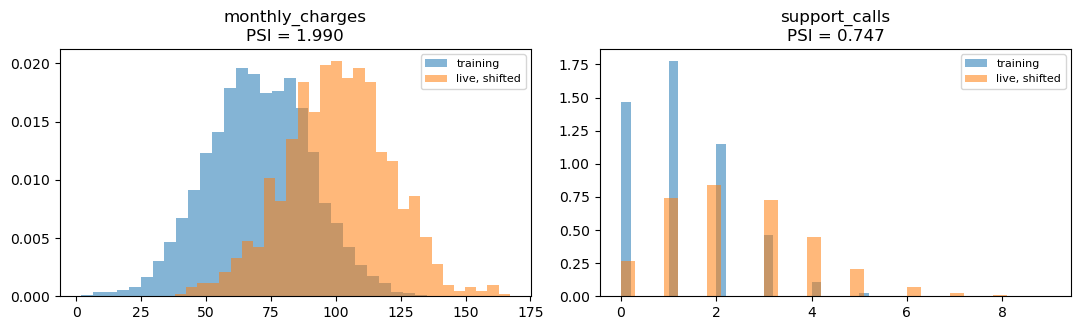

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.4))
for ax, column in zip(axes, ("monthly_charges", "support_calls")):
    ax.hist(reference[column].dropna(), bins=30, density=True, alpha=.55, label="training")
    ax.hist(moved_world[column].dropna(), bins=30, density=True, alpha=.55, label="live, shifted")
    ax.set_title(f"{column}\nPSI = {psi(reference[column], moved_world[column]):.3f}")
    ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

### Evidence 3: a drift signal that fires only when it should

The same check over a sliding window, with the world moving partway through.

 window  shift  psi_charges  psi_calls
      0   0.00       0.0203     0.0097
      1   0.00       0.0183     0.0020
      2   0.00       0.0201     0.0012
      3   0.00       0.0096     0.0027
      4   0.00       0.0231     0.0022
      5   0.00       0.0104     0.0009
      6   0.25       0.0697     0.0228
      7   0.50       0.4622     0.1750
      8   0.75       0.9166     0.3916
      9   1.00       1.3461     0.4605
     10   1.25       2.0363     0.8088
     11   1.50       3.4986     1.1287


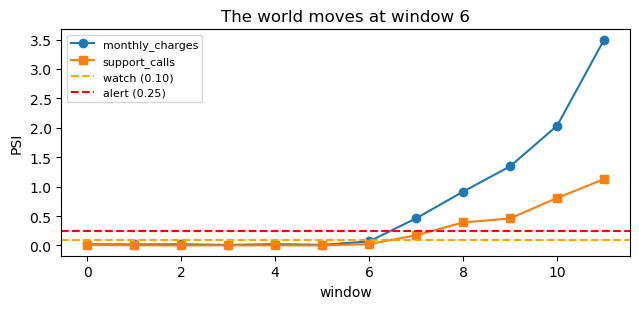

In [10]:
windows = []
for step in range(12):
    shift = 0.0 if step < 6 else (step - 5) * 0.25
    window, _ = make_data(n=600, seed=200 + step, shift=shift)
    windows.append({"window": step, "shift": round(shift, 2),
                    "psi_charges": psi(reference.monthly_charges, window.monthly_charges),
                    "psi_calls": psi(reference.support_calls, window.support_calls)})

drift = pd.DataFrame(windows)
print(drift.round(4).to_string(index=False))

plt.figure(figsize=(6.5, 3.2))
plt.plot(drift.window, drift.psi_charges, "o-", label="monthly_charges")
plt.plot(drift.window, drift.psi_calls, "s-", label="support_calls")
plt.axhline(0.10, ls="--", color="orange", label="watch (0.10)")
plt.axhline(0.25, ls="--", color="red", label="alert (0.25)")
plt.xlabel("window"); plt.ylabel("PSI"); plt.legend(fontsize=8)
plt.title("The world moves at window 6"); plt.tight_layout(); plt.show()

The signal is flat while the world is stable and climbs once it is not. What it
does **not** tell you is whether the model got worse — for that you need labels,
which arrive later if at all. PSI answers "are the inputs still the inputs?",
and that is a question you can answer today.

## 5. The container, and the model card

In [11]:
(SERVICE / "requirements.txt").write_text('''# Serving dependencies, pinned tightly on purpose: the container is the
# reproducibility boundary. Loosen these and "it worked last month" begins.
fastapi==0.115.6
uvicorn[standard]==0.34.0
pydantic==2.10.4
scikit-learn==1.7.2
pandas==2.3.3
numpy==2.3.4
joblib==1.4.2
''')

(SERVICE / "Dockerfile").write_text('''FROM python:3.11-slim

# Never root: a compromised process should not own the container.
RUN useradd --create-home --uid 10001 service
WORKDIR /srv

COPY requirements.txt .
RUN pip install --no-cache-dir -r requirements.txt

COPY app.py schema.py model.joblib metadata.json ./
USER service

EXPOSE 8000
HEALTHCHECK --interval=30s --timeout=3s \\
  CMD python -c "import urllib.request,sys; sys.exit(0 if urllib.request.urlopen('http://localhost:8000/health').status==200 else 1)"

CMD ["uvicorn", "app:app", "--host", "0.0.0.0", "--port", "8000"]
''')

(SERVICE / "MODEL_CARD.md").write_text(f'''# Model card — churn service {json.loads((SERVICE / "metadata.json").read_text())["test_roc_auc"]} test ROC-AUC

**Version** 2026.08.1 · trained on synthetic course data, not on customers.

## Intended use
Ranking accounts for a retention team's review queue. It is a triage aid, not a
decision, and it must not be used to set prices or deny service.

## Inputs
`tenure_months`, `monthly_charges` (may be missing), `support_calls`, `plan`,
`region`. Validation and ranges are in `schema.py`; anything outside them is
rejected rather than guessed.

## Training data
6000 synthetic rows, 5% of `monthly_charges` missing by construction.

## Evaluation
Held-out 25% split; ROC-AUC reported in `metadata.json`. No fairness audit has
been run: the synthetic data carries no protected attribute, and a real
deployment would require one (see Session 30).

## Limitations
- The threshold is fixed at 0.5 and has not been chosen against a cost model.
- No monitoring of outcomes, only of inputs (`monitor.py`, PSI).
- Retraining cadence undefined.

## Contact
Course staff, CS 4771/5771.
''')

for name in sorted(p.name for p in SERVICE.iterdir() if p.is_file()):
    print(f"  {name}")

  Dockerfile
  MODEL_CARD.md
  app.py
  metadata.json
  model.joblib
  monitor.py
  reference_sample.csv
  requirements.txt
  schema.py
  test_app.py
  train.py


The Docker commands, to run in a terminal rather than here:

```bash
cd session29_service
docker build -t churn-service:2026.08.1 .
docker run --rm -p 8000:8000 churn-service:2026.08.1
curl localhost:8000/health
curl -X POST localhost:8000/predict -H 'content-type: application/json' \
     -d '{"tenure_months": 4, "monthly_charges": 95, "support_calls": 5,
          "plan": "basic", "region": "north"}'
```

**If Docker is not available**, the fallback is one line and gives you the same
service on the same port — this is the path the teaching plan uses when the lab
machines will not cooperate:

```bash
cd session29_service && uvicorn app:app --port 8000
```

## What to take from this

- Save the **pipeline**, not the model. One implementation of the preprocessing,
  travelling with the weights, is the whole defence against training/serving
  skew — and the notebook proved it by matching the API bit for bit.
- The schema is the contract. Five malformed requests, five rejections, no model
  call.
- Tests keep the contract true when someone edits the app.
- Monitor the inputs, because the labels are late. PSI answers "are the inputs
  still the inputs?" and nothing more.
- Pin the serving dependencies, run as a non-root user, and keep a model card
  that says what the model must *not* be used for.

## Where to go next

- **Reading, Session 29** — the production gap, registries, containers, and
  monitoring.
- **`session29_service/`** — the whole service is next to this notebook. Add a
  field to `schema.py` and watch `test_app.py` fail before it passes.
- **Session 30** — the audit this model card admits it has not had.